In [1]:
# Import required libraries for data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
# sep="\t" because SMS spam dataset is tab-separated
# header=None because file does not contain column names

df = pd.read_csv("dataset.csv", sep="\t", header=None)

# Display first 5 rows of the dataset
df.head()


,0,1
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Rename columns for better understanding
df.columns = ['target', 'text']

# Check updated dataframe
df.head()


,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Check number of rows and columns
df.shape


(5572, 2)

In [5]:
#DATA CLEANING PART :- 

In [6]:
# Check for missing values in each column
df.isnull().sum()


target    0
text      0
dtype: int64

In [7]:
# Check number of duplicate rows
df.duplicated().sum()


np.int64(403)

In [8]:
# Remove duplicate rows
df = df.drop_duplicates(keep='first')

# Check new shape after removing duplicates
df.shape


(5169, 2)

In [9]:
#EDA (Exploratory Data Analysis)

In [10]:
# Check how many spam and ham messages are present
df['target'].value_counts()


target
ham     4516
spam     653
Name: count, dtype: int64

In [11]:
# Convert target column into numeric form
# ham -> 0
# spam -> 1

df['target'] = df['target'].map({'ham': 0, 'spam': 1})

df.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


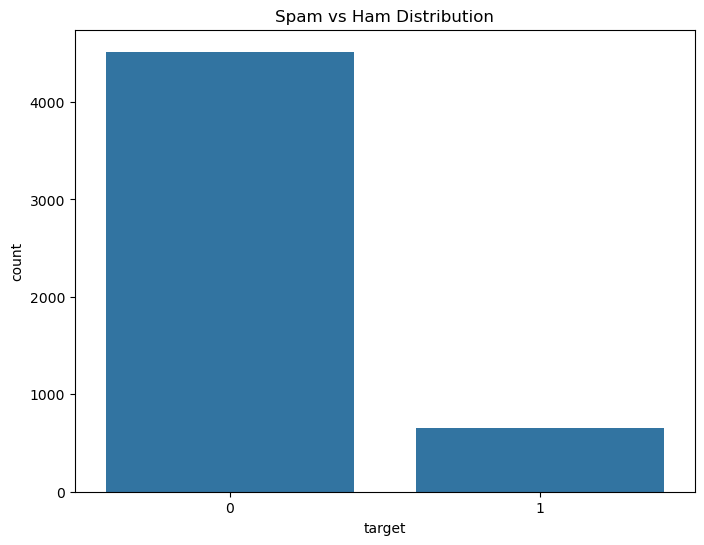

In [12]:
# Visualize the distribution of spam and ham messages

plt.figure(figsize=(8,6))
sns.countplot(x='target', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()


In [13]:
# Create a new column for message length
df['message_length'] = df['text'].apply(len)

df.head()


,target,text,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [14]:
# Check average message length for ham and spam
df.groupby('target')['message_length'].describe()


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
1,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


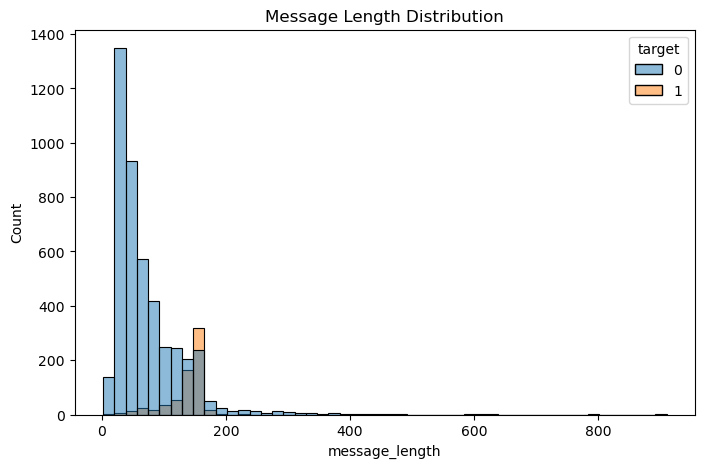

In [15]:
# Plot histogram of message length

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='message_length', hue='target', bins=50)
plt.title("Message Length Distribution")
plt.show()


In [16]:
# Create a new column for word count
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

df.head()


,target,text,message_length,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [17]:
# Compare word count statistics for spam and ham
df.groupby('target')['word_count'].describe()


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4516.0,14.239814,11.179471,1.0,7.0,11.0,19.0,171.0
1,653.0,23.739663,5.931064,2.0,22.0,25.0,28.0,35.0


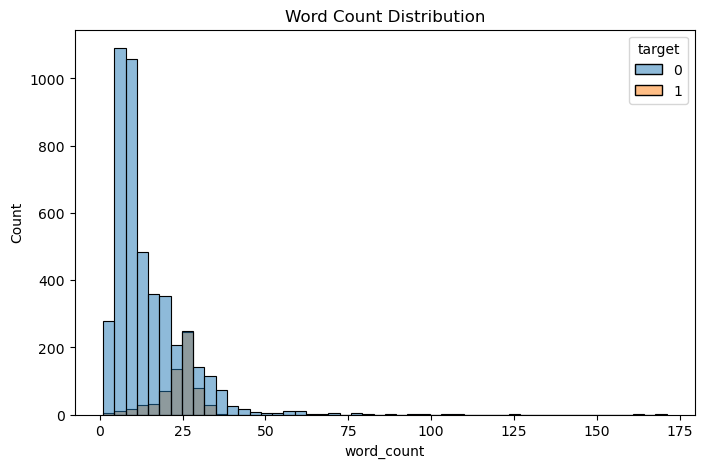

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='word_count', hue='target', bins=50)
plt.title("Word Count Distribution")
plt.show()


In [19]:
#TEXT PREPROCESSING

In [20]:
!pip install nltk


Defaulting to user installation because normal site-packages is not writeable


In [21]:
# Import text processing tools
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string


In [22]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lucky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lucky\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
# Create a function to clean and preprocess text

ps = PorterStemmer()

def transform_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Tokenization (split text into words)
    text = nltk.word_tokenize(text)
    
    y = []
    
    # Remove special characters
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    # Remove stopwords and apply stemming
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(ps.stem(i))
    
    return " ".join(y)


In [24]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lucky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lucky\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
import nltk

nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lucky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [26]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()


,target,text,message_length,word_count,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,nah think goe usf live around though


In [27]:
#TF-IDF Vectorization

In [28]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer


In [29]:
# Create TF-IDF object (max 5000 important words)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

In [30]:
# Convert text data into numerical vectors

X = tfidf.fit_transform(df['transformed_text'])

In [31]:
# Target variable (Spam = 1, Ham = 0)
y = df['target'].values


In [32]:
# Target variable (Spam = 1, Ham = 0)
from sklearn.model_selection import train_test_split

# Split dataset into training and testing data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [33]:
#Naive Bayes Model

In [34]:
# Import Multinomial Naive Bayes model
from sklearn.naive_bayes import MultinomialNB
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix


In [35]:
# Create model object
mnb = MultinomialNB(alpha=0.1)


In [36]:
# Train the model using training data
mnb.fit(X_train, y_train)


,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


In [37]:
# Make predictions on test data
y_pred = mnb.predict(X_test)


In [38]:
# Print evaluation results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))


Accuracy: 0.9806576402321083
Precision: 0.9545454545454546


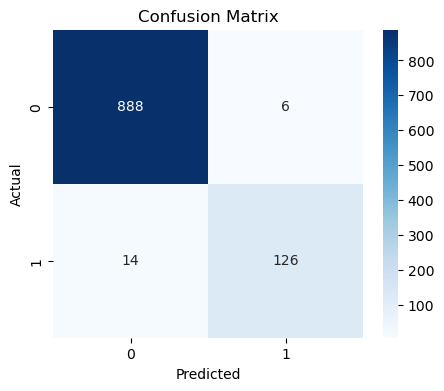

In [39]:
# Import seaborn and matplotlib for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       894
           1       0.95      0.90      0.93       140

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [41]:
import pickle

pickle.dump(mnb, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))
